<a href="https://colab.research.google.com/github/pametoro/Parcial_1_programacion_ciencia_datos/blob/main/Parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Evaluación parcial 1**

Integrantes:
*   Alejandra Marambio
*   Pamela Toro



# Introducción

El presente proyecto se enmarca en el análisis y procesamiento de datos para la toma de decisiones informadas. Se nos ha hecho entrega de un conjunto de datos en formato CSV, el cual contiene información detallada sobre las preferencias alimentarias de diversos individuos, integrando variables demográficas como edad, género y nacionalidad, junto con hábitos de consumo de alimentos, bebidas y postres.

El objetivo principal de este trabajo es realizar un flujo completo de Ciencia de Datos que abarque desde la carga inicial hasta la preparación de un dataset optimizado. Para ello, el desarrollo se centrará en dos pilares fundamentales:

Auditoría y Limpieza de Datos: Identificar y corregir inconsistencias críticas detectadas en la exploración inicial, tales como valores nulos, registros duplicados y datos atípicos (outliers) en la variable de edad, donde se presentan valores inconsistentes con la realidad biológica.

Optimización de Recursos: Implementar técnicas avanzadas de programación para mejorar la eficiencia del procesamiento y el uso de memoria RAM.

A través de este análisis, se busca transformar una fuente de datos cruda y con ruido en un activo de información estructurado, normalizado y listo para ser utilizado en modelos predictivos o reportes estadísticos de alta precisión.

In [150]:
# Importar librerias:

import pandas as pd # fundamental para la manipulación de datos en tablas (DataFrames)
import numpy as np # utilizada para operaciones numéricas avanzadas y manejo de valores nulos.
import matplotlib.pyplot as plt # librería base para la creación de gráficos.
import seaborn as sns # basada en matplotlib, permite crear gráficos estadísticos más atractivos y complejos con menos código.
from sklearn.impute import SimpleImputer # para completar valores faltantes (nulos) de forma automática.
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, LabelEncoder # para escalar datos numéricos y convertir texto a números (codificación).
from sklearn.compose import ColumnTransformer # permite aplicar diferentes transformaciones a columnas específicas simultáneamente.
from sklearn.pipeline import Pipeline # para encadenar varios pasos de procesamiento en un solo objeto, evitando errores de fuga de datos.

**Carga y exploración inicial:**
- Cargar el dataset entregado.
- Analizar los datos, por ejemplo, tipos de datos, estadística descriptiva, clasificación de variables, mostrar información relevante a partir de agrupaciones (groupby), etc.
- Identificar la existencia de valores faltantes (nulos).
- Determinar la existencia de registros duplicados.
- Detectar outliers (valores atípicos).
- Identificar errores tipográficos en variables categóricas.
- Hacer graficos


In [151]:
# cargar el dataset:
# se usa read_csv porque el archivo csv tiene formato de valores separados por comas.
data = pd.read_csv('Food_Preference(1).csv')

In [152]:
# Analizar los datos
data.head() # muestra las primeras 5 filas para tener una vista rápida de los datos.

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,2019/05/07 2:59:13 PM GMT+8,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,2019/05/07 3:00:05 PM GMT+8,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,2019/05/07 3:00:11 PM GMT+8,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


In [153]:
data.info()
# muestra los tipos de datos (object, float) y cuántos valores no nulos hay en cada columna.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       290 non-null    object 
 1   Participant_ID  290 non-null    object 
 2   Gender          284 non-null    object 
 3   Nationality     290 non-null    object 
 4   Age             288 non-null    float64
 5   Food            290 non-null    object 
 6   Juice           290 non-null    object 
 7   Dessert         290 non-null    object 
dtypes: float64(1), object(7)
memory usage: 18.3+ KB


In [154]:
data.shape
# indica las dimensiones del dataset (filas, columnas).

(290, 8)

In [155]:
# Estadística descriptiva:
data.describe(include='O')
# resumen de las variables categóricas:
# count: cantidad de datos por columnas
# unique: cantidad de variables distintas
# top: dato que más se repite
# freq: frecuencia

,Timestamp,Participant_ID,Gender,Nationality,Food,Juice,Dessert
count,290,290,284,290,290,290,290
unique,285,288,5,28,7,2,3
top,2019/05/10 1:07:43 AM GMT+8,FPS002,Female,Indian,Traditional food,Fresh Juice,Maybe
freq,2,2,165,242,236,257,123


In [156]:
data.describe()
# genera estadísticas de las variables numéricas (media, desviación, min/max)

,Age
count,288.000000
mean,31.625000
std,20.843326
min,-47.000000
25%,24.000000
50%,28.000000
75%,37.000000
max,263.000000


In [157]:
# Identificar la existencia de valores faltantes (nulos)
data.isna().sum()
# isna().sum() --> permite cuantificar cuánta información falta en cada variable para decidir estrategias de imputación.

,0
Timestamp,0
Participant_ID,0
Gender,6
Nationality,0
Age,2
Food,0
Juice,0
Dessert,0


In [158]:
# Determinar la existencia de registros duplicados
data.duplicated().sum()
# duplicated().sum() --> detecta si hay filas idénticas que puedan sesgar el análisis estadístico.

np.int64(2)

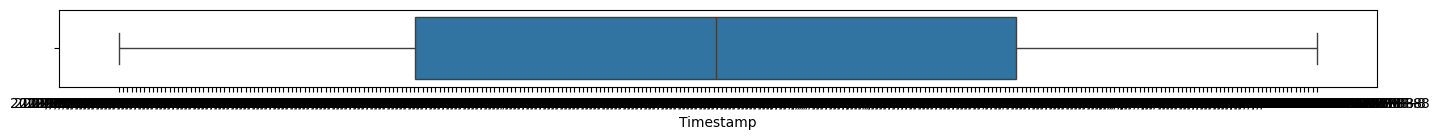

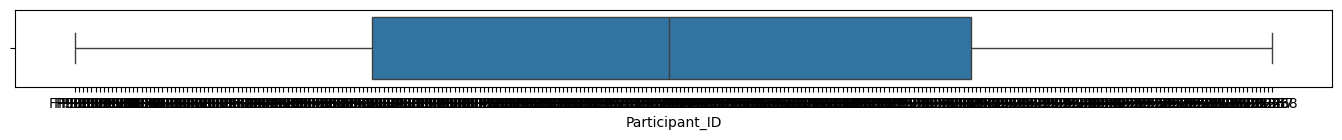

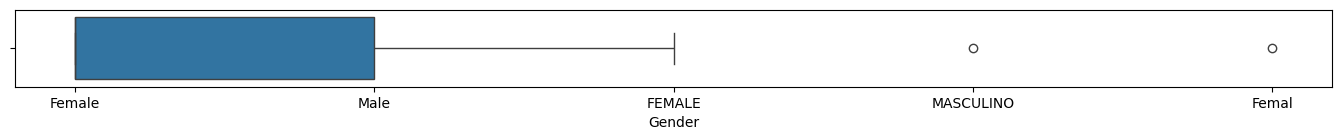

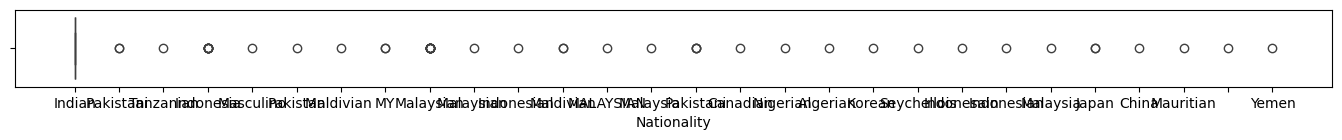

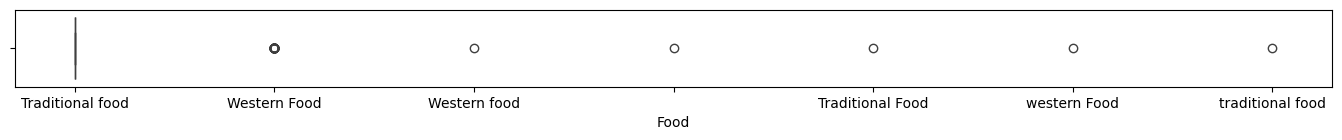

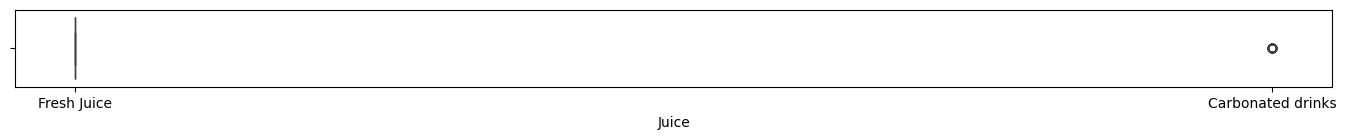

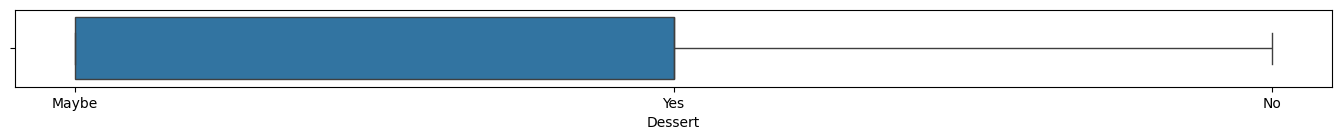

In [159]:
# Detectar outliers (valores atípicos)

# se utiliza select_dtypes para separar columnas y sns.boxplot para visualizar si hay datos fuera de los rangos normales (outliers)

num_cols=data.select_dtypes(include='O').columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=data[num_cols], x=col)

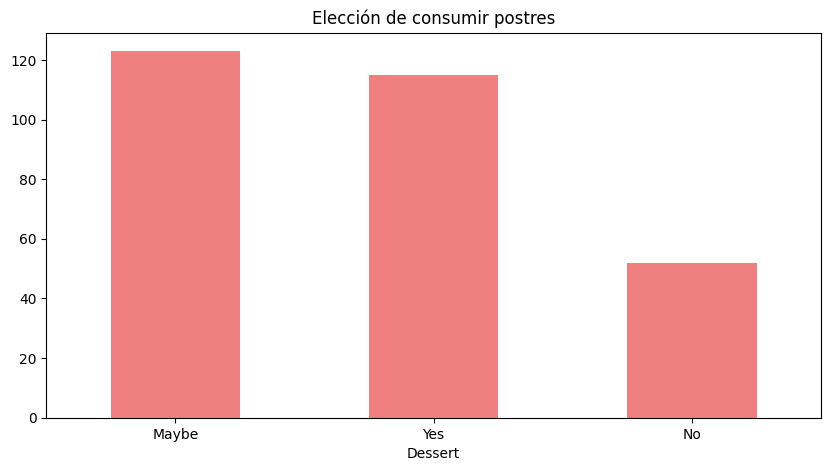

In [160]:
# Gráfico de algunas variables categóricas

plt.figure(figsize=(10, 5)) # esto define el área total de trabajo en pulgadas.
data['Dessert'].value_counts().plot(kind='bar', color='lightcoral', rot=0)
# calcula la frecuencia de cada categoría en 'Dessert', crea un gráfico de barras de color coral.
# 'kind=bar' define el tipo de gráfico y 'rot=0' mantiene las etiquetas del eje X horizontales.
plt.title('Elección de consumir postres') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show() # muestra el gráfico final en pantalla

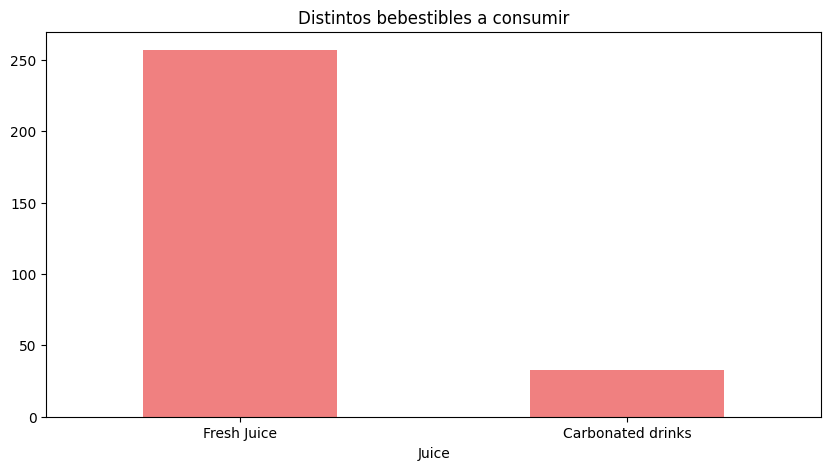

In [161]:
plt.figure(figsize=(10, 5))
data['Juice'].value_counts().plot(kind='bar', color='lightcoral', rot=0)
# calcula la frecuencia de cada categoría en 'Juice', crea un gráfico de barras de color coral.
# 'kind=bar' define el tipo de gráfico y 'rot=0' mantiene las etiquetas del eje X horizontales.
plt.title('Distintos bebestibles a consumir') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show() # muestra el gráfico final en pantalla

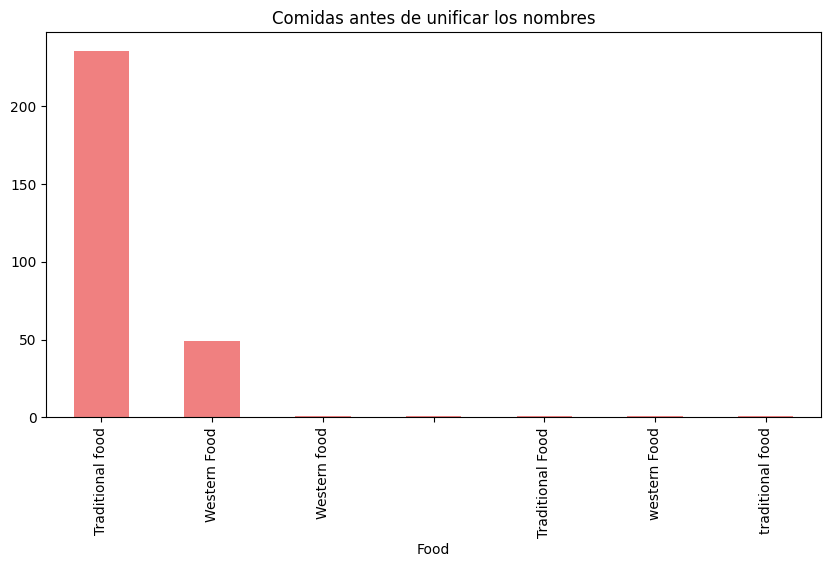

In [162]:
# Identificar errores tipográficos en variables categóricas
plt.figure(figsize=(10, 5))
data['Food'].value_counts().plot(kind='bar', color='lightcoral')
# calcula la frecuencia de cada categoría en 'Food', crea un gráfico de barras de color coral y 'kind=bar' define el tipo de gráfico.
plt.title('Comidas antes de unificar los nombres') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show() # muestra el gráfico final en pantalla

In [163]:
# Identificar errores tipográficos en variables categóricas
print(data['Food'].unique())
# muestra una lista de todos los tipos de comida sin repetir ninguno.

['Traditional food' 'Western Food' 'Western food' ' ' 'Traditional Food'
 'western Food' 'traditional food']


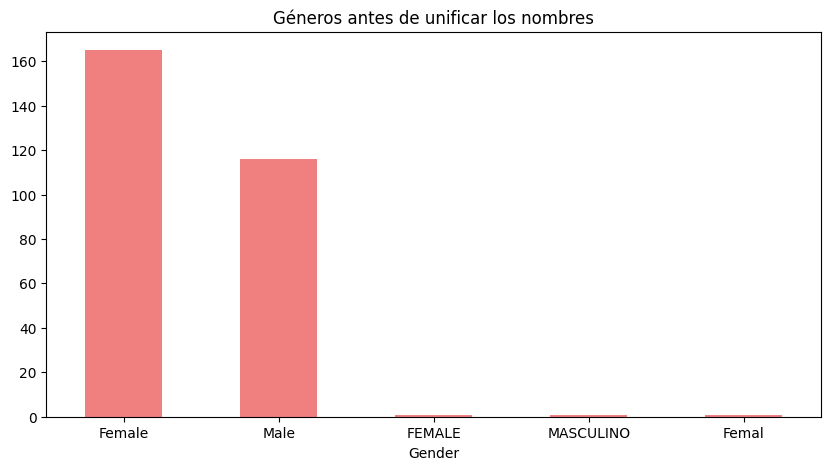

In [164]:
plt.figure(figsize=(10, 5))
data['Gender'].value_counts().plot(kind='bar', color='lightcoral', rot=0)
# calcula la frecuencia de cada categoría en 'Gender', crea un gráfico de barras de color coral.
# 'kind=bar' define el tipo de gráfico y 'rot=0' mantiene las etiquetas del eje X horizontales.
plt.title('Géneros antes de unificar los nombres') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show() # muestra el gráfico final en pantalla

In [165]:
# Identificar errores tipográficos en variables categóricas
print(data['Gender'].unique())
# muestra una lista de todos los tipos de género sin repetir ninguno.

[nan 'Female' 'Male' 'FEMALE' 'MASCULINO' 'Femal']


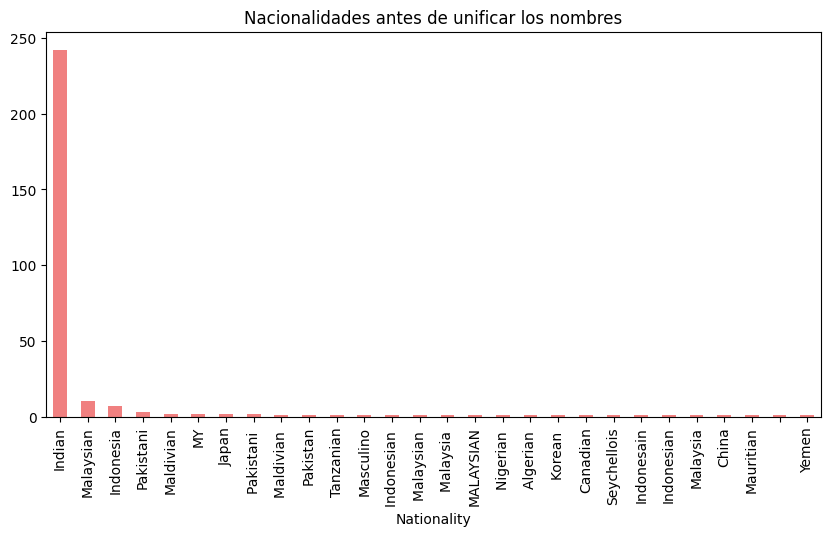

In [166]:
plt.figure(figsize=(10, 5))
data['Nationality'].value_counts().plot(kind='bar', color='lightcoral')
# calcula la frecuencia de cada categoría en 'Nationality', crea un gráfico de barras de color coral y 'kind=bar' define el tipo de gráfico
plt.title('Nacionalidades antes de unificar los nombres') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show() # muestra el gráfico final en pantalla

In [167]:
# Identificar errores tipográficos en variables categóricas
print(data['Nationality'].unique())
# muestra una lista de todos los tipos de nacionalidades sin repetir ninguno.

['Indian' 'Pakistani ' 'Tanzanian' 'Indonesia' 'Masculino' 'Pakistan'
 'Maldivian ' 'MY' 'Malaysian' 'Malaysian ' 'Indonesian ' 'Maldivian'
 'MALAYSIAN' 'Malaysia ' 'Pakistani' 'Canadian' 'Nigerian ' 'Algerian '
 'Korean ' 'Seychellois' 'Indonesain' 'Indonesian' 'Malaysia' 'Japan'
 'China' 'Mauritian' ' ' 'Yemen']


# **Manipulación de datos:**
- Selección de columnas relevantes.
- Filtrado de filas.
- Joins, merges y concatenaciones simples, si corresponde.


In [168]:
# Selección de columnas relevantes:

# no usamos 'Timestamp' y 'Participant_ID' --> porque no aportan patrones estadísticos.
columnas_estudio = ['Gender', 'Nationality', 'Age', 'Food', 'Juice', 'Dessert']
data_col_relevante = data[columnas_estudio].copy() # crear el dataframe filtrado
data_col_relevante.head() # mostrar las primeras filas para verificar la selección

,Gender,Nationality,Age,Food,Juice,Dessert
0,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


In [169]:
# Filtrado de filas

# eliminar los datos que esten fuera de este rango
data = data[data['Age'].between(5, 99)]

- En relación al contexto nosotras definimos la edad desde 5 a 99 años, ya que encontramos razonable que desde dicha edad un niño/a ya pueda decidir sus preferencias alimentarias.

In [ ]:
# joins, merges y concatenaciones simples, si corresponde

- No es necesario usar joins, merges y concatenaciones simples, ya que el archivo csv de food preference solo cuenta con una hoja.

# **Limpieza:**
- Tratar valores faltantes (eliminar o imputar).
- Eliminar registros duplicados.
- Tratar los outliers identificados.
-	Unificar mayúsculas/minúsculas en columnas de texto.
-	Corregir errores tipográficos en variables categóricas.
- Hacer graficos


In [170]:
# Tratar valores faltantes (eliminar o imputar)
print(f'datos nulos antes : {data.isna().sum()}')
# eliminar filas con faltantes (genero)
data.dropna(subset=['Gender'], inplace=True)

datos nulos antes : Timestamp         0
Participant_ID    0
Gender            6
Nationality       0
Age               0
Food              0
Juice             0
Dessert           0
dtype: int64


In [171]:
# rellena los valores nulos de la columna 'Age' usando la mediana de la misma columna edad.
data['Age'] = data['Age'].fillna(data['Age'].median())

print(f'\nDatos nulos después:\n{data.isna().sum()}')


Datos nulos después:
Timestamp         0
Participant_ID    0
Gender            0
Nationality       0
Age               0
Food              0
Juice             0
Dessert           0
dtype: int64


In [172]:
# Eliminar registros duplicados

# cuenta y muestra el total de filas que son idénticas entre sí en el dataset.
print(f'Filas duplicadas: {data.duplicated().sum()}')

# elimina las filas repetidas permanentemente (inplace=True) dejando solo la primera aparición.
data.drop_duplicates(inplace=True)

# verifica nuevamente el conteo para confirmar que ahora el total de duplicados es 0.
print(f'Filas actualizadas {data.duplicated().sum()}')

Filas duplicadas: 2
Filas actualizadas 0


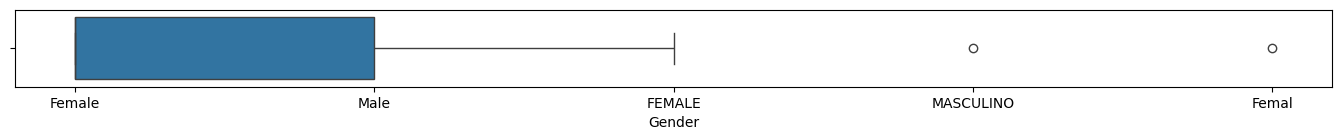

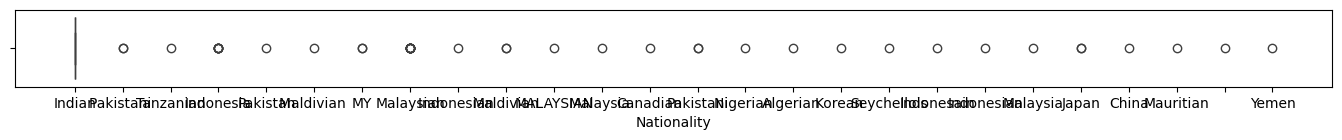

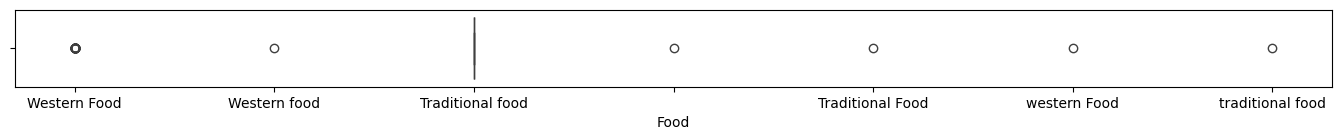

In [178]:
# tratar outliers identificados
num_cols=data[['Gender', 'Nationality', 'Food']].columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=data[num_cols], x=col)

In [132]:
# unificar mayusculas/minusculas en columnas de texto
# Poner todo en minúsculas, quitar espacios al inicio/final y quitar acentos
#df['Nombre_variable'] = df['Nombre_variable'].str.lower().str.strip().str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

In [181]:
# corregir errores tipograficos en variables categoricas

# Definimos qué nombres queremos cambiar y por cuál
cambios = {
    'Female': 'Femenino',
    'FEMALE': 'Femenino',
    'Femal': 'Femenino',
    'Male' : 'Masculino',
    'MASCULINO' : 'Masculino'
}

# Aplicamos los cambios a la columna
data['Gender'] = data['Gender'].replace(cambios)

#verificamos los cambios
print(data['Gender'].value_counts())

Gender
femenino     163
masculino    113
Name: count, dtype: int64


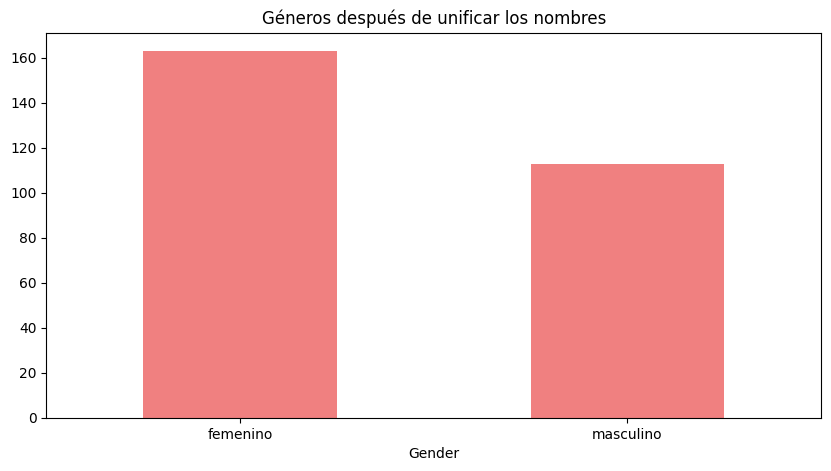

In [182]:
# volver a realizar graficos

plt.figure(figsize=(10, 5))
data['Gender'].value_counts().plot(kind='bar', color='lightcoral', rot=0)
# calcula la frecuencia de cada categoría en 'Gender', crea un gráfico de barras de color coral.
# 'kind=bar' define el tipo de gráfico y 'rot=0' mantiene las etiquetas del eje X horizontales.
plt.title('Géneros después de unificar los nombres') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show()

In [184]:
cambios_2 = {
    'Traditional food': 'Traditional food',
    'Traditional Food': 'Traditional food',
    'traditional food': 'Traditional food',
    'western food': 'Western food',
    'Western food': 'Western food',
    'Western Food': 'Western food',
    'western Food': 'Western food'
}

data['Food'] = data['Food'].replace(cambios_2)
print(data['Food'].value_counts())

Food
Traditional food    226
Western food         49
                      1
Name: count, dtype: int64


In [185]:
# hay que eliminar el food sin nada o imputar con comida tradicional (por moda)
data = data[data['Food'] != ' ']

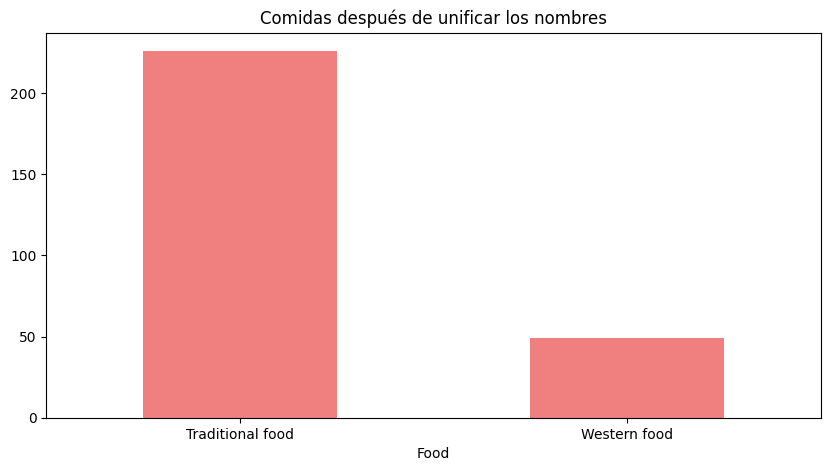

In [186]:
# volver a realizar graficos

plt.figure(figsize=(10, 5))
data['Food'].value_counts().plot(kind='bar', color='lightcoral', rot= 0)
# calcula la frecuencia de cada categoría en 'Food', crea un gráfico de barras de color coral.
# 'kind=bar' define el tipo de gráfico y 'rot=0' mantiene las etiquetas del eje X horizontales.
plt.title('Comidas después de unificar los nombres') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show()

In [197]:
cambios_3 = {
    'Indian': 'Indian',
    'Pakistani ': 'Pakistani',
    'Pakistan': 'Pakistani',
    'Pakistani': 'Pakistani',
    'Tanzanian': 'Tanzanian',
    'Indonesia': 'Indonesian',
    'Indonesian ': 'Indonesian',
    'Indonesain': 'Indonesian',
    'Indonesian': 'Indonesian',
    'Maldivian ': 'Maldivian',
    'Maldivian': 'Maldivian',
    'MY': 'Malaysian',
    'Malaysian': 'Malaysian',
    'Malaysian ': 'Malaysian',
    'MALAYSIAN': 'Malaysian',
    'Malaysia ': 'Malaysian',
    'Malaysia': 'Malaysian',
    'Canadian': 'Canadian',
    'Nigerian ': 'Nigerian',
    'Algerian ': 'Algerian',
    'Korean ': 'Korean',
    'Seychellois': 'Seychellois',
    'Japan': 'Japanese',
    'China': 'Chinese',
    'Mauritian': 'Mauritian',
    'Yemen' : 'Yemení'
}

data['Nationality'] = data['Nationality'].replace(cambios_3)
print(data['Nationality'].value_counts())

Nationality
Indian         232
Malaysian       15
Indonesian       8
Pakistani        5
Maldivian        3
Japanese         2
Tanzanian        1
Canadian         1
Nigerian         1
Korean           1
Algerian         1
Seychellois      1
Chinese          1
Mauritian        1
Yemení           1
Name: count, dtype: int64


In [188]:
# eliminar de de nationality masculino y ''
data = data[data['Nationality'] != ' ']

In [189]:
data = data[data['Nationality'] != 'Masculino']

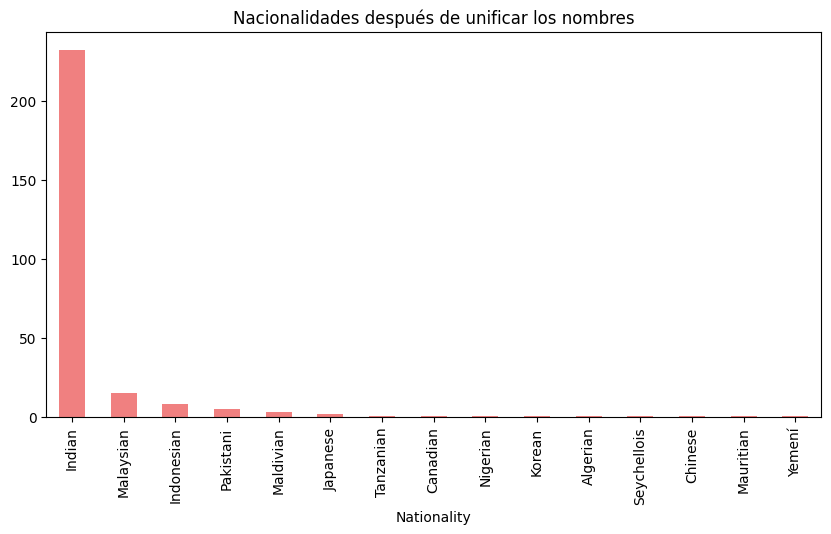

In [190]:
plt.figure(figsize=(10, 5))
data['Nationality'].value_counts().plot(kind='bar', color='lightcoral')
# calcula la frecuencia de cada categoría en 'Nationality', crea un gráfico de barras de color coral y 'kind=bar' define el tipo de gráfico
plt.title('Nacionalidades después de unificar los nombres') # agrega un título descriptivo en la parte superior para contextualizar la información.
plt.show()

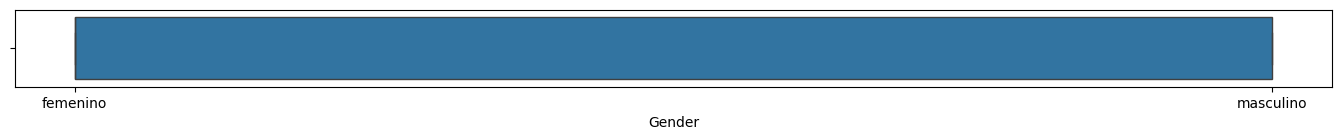

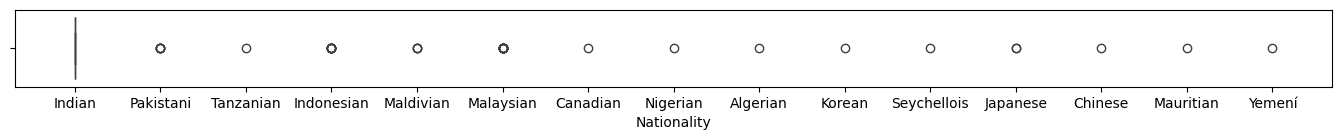

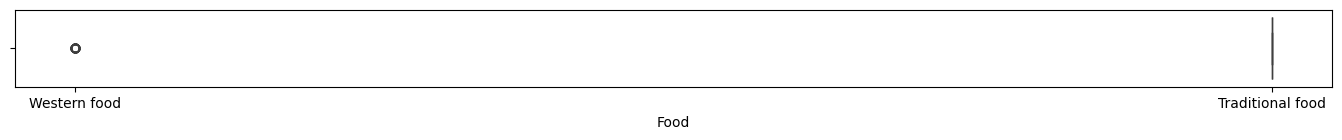

In [191]:
# Volver a mostrar los outliers identificados
num_cols=data[['Gender', 'Nationality', 'Food']].columns
for col in num_cols:
  plt.figure(figsize=(17,1))
  sns.boxplot(data=data[num_cols], x=col)

# Transformación:
- Crear agregaciones a partir de las variables originales (crear nuevas variables), si corresponde.
- Definir y utilizar un(os) Pipeline(s) que contenga(n) los siguientes preprocesamientos:
-- Codificación de variables categóricas.
-- Escalamiento de variables numéricas.


In [ ]:
#Crear agregaciones a partir de las variables originales (crear nuevas variables), si corresponde

+ No vamos a agregar nuevas variables, ya que no lo encontramos necesario para procesar los datos.

In [192]:
# Mostramos los datos de las columnas categóricas seleccionadas
print(data[['Juice', 'Gender', 'Food', 'Dessert']])

                 Juice     Gender              Food Dessert
1    Carbonated drinks   femenino      Western food     Yes
3          Fresh Juice  masculino      Western food   Maybe
4          Fresh Juice   femenino  Traditional food   Maybe
6          Fresh Juice  masculino  Traditional food     Yes
7          Fresh Juice   femenino  Traditional food     Yes
..                 ...        ...               ...     ...
285        Fresh Juice  masculino      Western food     Yes
286        Fresh Juice  masculino  Traditional food     Yes
287        Fresh Juice  masculino  Traditional food     Yes
288        Fresh Juice  masculino  Traditional food     Yes
289        Fresh Juice  masculino  Traditional food      No

[274 rows x 4 columns]


In [193]:
# Pipeline: codificar variables categoricas y escalar 'Age'
#Definición de un transformador de columnas (Pipeline inicial)
#Este primer bloque aplica OneHotEncoder a las categorías y StandardScaler a la edad.

pipeline = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(), ['Juice', 'Gender', 'Food', 'Dessert']),# Convierte texto a columnas binarias (0 y 1)
    ('num', StandardScaler(), ['Age']),# Escala la edad para que tenga media 0 y desviación estándar 1
])

X_transf = pipeline.fit_transform(data)
print('X_transf (first pipeline output):')
print(X_transf[:5])

# Definimos qué columnas son numéricas
numerica_f = ["Age"]
# Creamos un sub-pipeline para números:
# Primero rellena vacíos con la mediana y luego escala los valores entre 0 y 1
numerica_t = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),# Maneja los "espacios en blanco" o NaNs
        ("scaler", MinMaxScaler())# Escala al rango [0, 1]
    ]
)
# Definimos las columnas categóricas
categoricas_f = ["Juice", "Gender", "Food", "Dessert"]
# Creamos un sub-pipeline para categorías:
# Aplica OneHotEncoding e ignora categorías nuevas que no vio en el entrenamiento
categoricas_t = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ])

# Unión de transformadores (ColumnTransformer)
# Aquí integramos los dos sub-pipelines anterior
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerica_t, numerica_f),
        ("cat", categoricas_t, categoricas_f)
    ]
)

# Ejecutamos todo el proceso sobre el DataFrame original
data_processed = preprocessor.fit_transform(data)
# Extraemos los nombres de las columnas resultantes
feature_names_out = preprocessor.get_feature_names_out()

# Convertimos la matriz resultante de nuevo a un DataFrame de Pandas para que sea legible
data_processed_df = pd.DataFrame(data_processed, columns=feature_names_out)

# Identificamos cuáles de las nuevas columnas son las categóricas
categorical_processed_columns = [col for col in feature_names_out if col.startswith('cat__')]

print('\nCategorical processed data (first 5 rows):')
display(data_processed_df[categorical_processed_columns].head())

# Mostramos resultados finales
print('\nFull processed data (first 5 rows):')
display(data_processed_df.head())

X_transf (first pipeline output):
[[ 1.          0.          1.          0.          0.          1.
   0.          0.          1.         -0.7782158 ]
 [ 0.          1.          0.          1.          0.          1.
   1.          0.          0.          0.01742274]
 [ 0.          1.          1.          0.          1.          0.
   1.          0.          0.         -0.51300295]
 [ 0.          1.          0.          1.          1.          0.
   0.          0.          1.         -0.60140724]
 [ 0.          1.          1.          0.          1.          0.
   0.          0.          1.          0.28263559]]

Categorical processed data (first 5 rows):


,cat__Juice_Carbonated drinks,cat__Juice_Fresh Juice,cat__Gender_femenino,cat__Gender_masculino,cat__Food_Traditional food,cat__Food_Western food,cat__Dessert_Maybe,cat__Dessert_No,cat__Dessert_Yes
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0



Full processed data (first 5 rows):


,num__Age,cat__Juice_Carbonated drinks,cat__Juice_Fresh Juice,cat__Gender_femenino,cat__Gender_masculino,cat__Food_Traditional food,cat__Food_Western food,cat__Dessert_Maybe,cat__Dessert_No,cat__Dessert_Yes
0,0.194444,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.319444,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
2,0.236111,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.222222,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0
4,0.361111,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


In [194]:
# label encoding

# usamos label encoding, ya que asigna a cada categoría (Nationality) un número entero único de forma arbitraria.
# recordando que el orden de estos números no tienen mayor importancia que el otro.

# 1. crear una copia exacta del dataframe original
# .copy() --> crea un objeto nuevo en la memoria, evitando que los cambios en data_copia alteren el data original
data_copia = data.copy()

# 2. aplicar label encoder en la copia
# transformar la columna 'Nationality' en números y la guardamos en una nueva columna
le = LabelEncoder()
data_copia['Nationality_label_encoded'] = le.fit_transform(data_copia['Nationality'])

# 3. visualizar el resultado
data_copia

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert,Nationality_label_encoded
1,2019/05/07 2:59:45 PM GMT+8,FPS002,femenino,Indian,22.0,Western food,Carbonated drinks,Yes,3
3,2019/05/07 3:00:05 PM GMT+8,FPS003,masculino,Indian,31.0,Western food,Fresh Juice,Maybe,3
4,2019/05/07 3:00:11 PM GMT+8,FPS004,femenino,Indian,25.0,Traditional food,Fresh Juice,Maybe,3
6,2019/05/07 3:03:34 PM GMT+8,FPS006,masculino,Indian,24.0,Traditional food,Fresh Juice,Yes,3
7,2019/05/07 3:03:48 PM GMT+8,FPS007,femenino,Indian,34.0,Traditional food,Fresh Juice,Yes,3
...,...,...,...,...,...,...,...,...,...
285,2019/05/10 9:24:00 AM GMT+8,FPS284,masculino,Indian,27.0,Western food,Fresh Juice,Yes,3
286,2019/05/10 9:32:54 AM GMT+8,FPS285,masculino,Indian,24.0,Traditional food,Fresh Juice,Yes,3
287,2019/05/10 12:09:17 PM GMT+8,FPS286,masculino,Indian,25.0,Traditional food,Fresh Juice,Yes,3
288,2019/05/10 12:52:17 PM GMT+8,FPS287,masculino,Indian,27.0,Traditional food,Fresh Juice,Yes,3


In [195]:
data_copia[['Nationality', 'Nationality_label_encoded']].drop_duplicates().sort_values('Nationality_label_encoded')
# este codigo nos muestra cada nacionalidad con su número asignado

,Nationality,Nationality_label_encoded
50,Algerian,0
43,Canadian,1
95,Chinese,2
1,Indian,3
13,Indonesian,4
85,Japanese,5
52,Korean,6
18,Malaysian,7
17,Maldivian,8
98,Mauritian,9


# **Exportación:**
- Guardar el resultado final en un nuevo archivo csv.


In [196]:
# Guardar el archivo

data.to_csv('preferencias_de_comidas.csv', index=False)